# S11 — Reflectivity pathology, all-variable ensembles, and the localization / spurious-correlation mechanism

Follow-up to S10. S10 showed the analysis `w` flips are *physical* at a single, isolated
observation. Here we go further:

1. **Problematic points are not only the `w` sign-flips.** We target points where the analysis
   **reflectivity error (RMSE, and CRPS where stored) is worse than both the prior and standard
   LETKF** — and then look at what the *whole ensemble* (all 8 variables) is doing there.
2. **We classify these points separately per condition** — single-obs sweep, multi-obs loc=0.1,
   multi-obs loc=2.0 (all Ne=59) — and compare the sets. Because the **sweep is equivalent to
   multi-obs at loc=0.1**, any point that is clean at loc=0.1 but pathological at loc=2.0 isolates
   the **localization effect**. We test the one-way hypothesis (clean-at-loc0.1 → bad-at-loc2.0,
   not the reverse).
3. **We reproduce the multi-obs LETKF locally** at representative points (Fortran solver on a
   subdomain with the point's real observation footprint), which (a) gives the full posterior
   ensemble for every variable and (b) lets us **decompose the increment into near vs far obs** and
   quantify how much of the far contribution is **spurious sampling correlation** (compared with the
   noise floor `sigma_var * sigma_h / sqrt(Ne-1)`).

Reflectivity is the *observed* field, so it often degrades only modestly even at loc=2.0 — the real
damage is in the unobserved `w`/`T`/`u`. We report both, honestly.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

REPO = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
D    = f'{REPO}/data'
sys.path.insert(0, f'{REPO}/src')
sys.path.insert(0, f'{REPO}/src/runners')
sys.path.insert(0, f'{REPO}/src/fortran')

import run_experiment as R                      # _subdomain_slices, _compute_rho (validated helpers)
from da.core import letkf_update, tenkf_update   # local reproduction of the multi-obs solve

VI   = {'qg':0,'qr':1,'qs':2,'T':3,'P':4,'u':5,'v':6,'w':7}
VARS = ['qg','qr','qs','T','P','u','v','w']
IW   = VI['w']
R0      = 5.0
DBZ_MIN = 0.0
TM      = 0
NX, NY, NZ = 558, 898, 11
PI, RD  = 3.14159265358979, 287.0
TOL = dict(qg=1e-6, qr=1e-6, qs=1e-6, T=1e-2, P=1.0, u=1e-3, v=1e-3, w=1e-3)

SWEEP  = f'{D}/WS_singleobs_xsec_1800_GUES/WS_singleobs_xsec_1800_GUES_sweep_Ne059_tm00.npz'
SUBSET = f'{D}/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'
MO = {  # both Ne=59, shared observation mask
    'loc0.1': (f'{D}/WS_diag1800_MO_L0.1_Ne59', 'WS_diag1800_MO_L0.1_Ne59', 'Lx0.1Ly0.1Lz0.1', 'Ne059'),
    'loc2.0': (f'{D}/WS_diag1800_MO_L2.0_Ne59', 'WS_diag1800_MO_L2.0_Ne59', 'Lx2.0Ly2.0Lz2.0', 'Ne059'),
}
FN = {'Nt1':'TEnKF_Nt01', 'Nt2':'TEnKF_Nt02', 'Nt3':'TEnKF_Nt03', 'AOEI':'AOEI_Nt01'}
LOCVAL = {'loc0.1': 0.1, 'loc2.0': 2.0}
def mo_ref(lk):        d,t,l,n = MO[lk]; return f'{d}/{t}_multi_obs_ref_{n}_tm00.npz'
def mo_combo(lk, st):  d,t,l,n = MO[lk]; return f'{d}/{t}_multi_obs_{FN[st]}_as1.0_{l}_{n}_tm00.npz'

# reflectivity forward operator H (vectorized port of calc_ref, validated against Fortran in S9/S10)
def calc_ref_np(qr, qs, qg, T, P, min_dbz=DBZ_MIN):
    qr, qs, qg, T, P = (np.asarray(a, np.float64) for a in (qr, qs, qg, T, P))
    nor, nos, nog = 8.0e6, 2.0e6, 4.0e6
    ror, ros, rog, roi = 1000.0, 100.0, 913.0, 917.0
    ki2, kr2 = 0.176, 0.930
    pip = PI ** 1.75
    cf  = 1e18 * 720.0 / (pip * nor**0.75 * ror**1.75)
    cf2 = 1e18 * 720.0 * ki2 * ros**0.25 / (pip * kr2 * nos**0.75 * roi**2.0)
    cf3 = 1e18 * 720.0 / (pip * nos**0.75 * ros**1.75)
    cf4 = (1e18 * 720.0 / (pip * nog**0.75 * rog**1.75)) ** 0.95
    ro = P / (RD * T)
    with np.errstate(invalid='ignore'):
        zr = np.where(qr > 0.0, cf * np.maximum(ro * qr, 0.0) ** 1.75, 0.0)
        zs = np.where(qs > 0.0, np.where(T <= 273.16, cf2, cf3) * np.maximum(ro * np.maximum(qs, 0.0), 0.0) ** 1.75, 0.0)
        zg = np.where(qg > 0.0, cf4 * np.maximum(ro * qg, 0.0) ** 1.6625, 0.0)
    z = zr + zs + zg
    ref = np.where(z > 0.0, 10.0 * np.log10(np.where(z > 0.0, z, 1.0)), min_dbz)
    return np.maximum(ref, min_dbz)

def Hmembers(state):
    return calc_ref_np(state[..., VI['qr']], state[..., VI['qs']], state[..., VI['qg']],
                       state[..., VI['T']],  state[..., VI['P']])
plt.rcParams['figure.dpi'] = 110
print('config ready')

config ready


## 1. Load the sweep (obs-space) and the multi-obs loc0.1 / loc2.0 reflectivity fields

In [2]:
d = np.load(SWEEP, allow_pickle=True)
method, ntemp = d['method'].astype(str), d['ntemp']
def rows(meth, nt):
    m = (method == meth) & (ntemp == nt)
    key = (d['i'][m].astype(np.int64) * 1000 + d['j'][m]) * 100 + d['k'][m]
    return m, np.argsort(key)
def col(name, m, o):
    return d[name][m][o].astype(np.float64)

COMBOS = {'AOEI': ('AOEI', 1), 'Nt1': ('TEnKF', 1), 'Nt2': ('TEnKF', 2), 'Nt3': ('TEnKF', 3)}
m_l, o_l = rows('TEnKF', 1)
I, J, K = d['i'][m_l][o_l], d['j'][m_l][o_l], d['k'][m_l][o_l]
npts = I.size

yo_cln = col('yo_clean',     m_l, o_l)     # noise-free truth reflectivity at the obs point
hxf    = col('hxf_mean_obs', m_l, o_l)     # prior mean H(x) [dBZ]
crps_f = col('crps_f_point_obs', m_l, o_l)
Ef_sw  = np.abs(hxf - yo_cln)              # SWEEP prior reflectivity error

Ea_sw, crps_a_sw = {}, {}
for n, (mm, nt) in COMBOS.items():
    m, o = rows(mm, nt)
    assert np.array_equal(d['i'][m][o], I) and np.array_equal(d['j'][m][o], J) and np.array_equal(d['k'][m][o], K)
    Ea_sw[n]    = np.abs(col('hxa_mean_obs', m, o) - yo_cln)   # SWEEP analysis reflectivity error
    crps_a_sw[n] = col('crps_a_point_obs', m, o)
print(f'{npts:,} sweep points loaded')

750,931 sweep points loaded


In [3]:
# multi-obs reflectivity error at the sweep points, per localization and per method
def field_at_pts(path, key):
    with np.load(path) as f:
        return f[key][I, J, K].astype(np.float64)

# shared observation mask (both MO runs pin to the same 693,783-pt set)
with np.load(mo_ref('loc2.0')) as r:
    IXO, IYO, IZO = r['ix'].copy(), r['iy'].copy(), r['iz'].copy()
    YOO = r['yo'].astype(np.float64).copy()
    TRUTH_HXO = r['truth_hx'].astype(np.float64)   # (nx,ny,nz)
obs_mask = np.zeros((NX, NY, NZ), bool); obs_mask[IXO, IYO, IZO] = True
with np.load(mo_ref('loc0.1')) as r:
    assert np.array_equal(r['ix'], IXO) and np.array_equal(r['iy'], IYO), 'MO masks differ'

Ef_mo, Ea_mo = {}, {}
for lk in ('loc0.1', 'loc2.0'):
    Ef_mo[lk] = np.abs(field_at_pts(mo_combo(lk, 'Nt1'), 'err_hxf_field'))    # |hxf_mean - truth_hx|
    Ea_mo[lk] = {n: np.abs(field_at_pts(mo_combo(lk, n), 'residual_field')) for n in COMBOS}

# common set: sweep points that are in the shared MO observation mask, k>=2, finite
common = obs_mask[I, J, K] & (K >= 2) & np.isfinite(Ef_sw) & np.isfinite(Ea_sw['Nt2'])
print(f'common observed points (k>=2): {int(common.sum()):,}')

# validations: same prior in sweep vs MO; SWEEP == MO loc0.1 for the analysis
d_prior = np.nanmax(np.abs(Ef_sw[common] - Ef_mo['loc0.1'][common]))
print(f'prior reflectivity error, sweep vs MO: max|diff| = {d_prior:.2e} dBZ')
for n in COMBOS:
    d_eq = np.nanmax(np.abs(Ea_sw[n][common] - Ea_mo['loc0.1'][n][common]))
    print(f'  SWEEP == MO loc0.1  [{n}] : max|diff| = {d_eq:.2e} dBZ')
assert np.nanmax(np.abs(Ea_sw['Nt1'][common] - Ea_mo['loc0.1']['Nt1'][common])) < 0.05, 'sweep != MO loc0.1'
print('EQUIVALENCE OK: the sweep reproduces multi-obs at loc=0.1')

common observed points (k>=2): 554,921
prior reflectivity error, sweep vs MO: max|diff| = 1.91e-06 dBZ
  SWEEP == MO loc0.1  [AOEI] : max|diff| = 3.89e-04 dBZ
  SWEEP == MO loc0.1  [Nt1] : max|diff| = 3.89e-04 dBZ
  SWEEP == MO loc0.1  [Nt2] : max|diff| = 1.04e-02 dBZ
  SWEEP == MO loc0.1  [Nt3] : max|diff| = 1.95e-02 dBZ
EQUIVALENCE OK: the sweep reproduces multi-obs at loc=0.1


## 2. Per-condition reflectivity pathology and the cross-condition set comparison

`patho_vs_prior(cond, method) = E_a > E_f` (the analysis reflectivity is worse than the prior).
Because SWEEP == MO loc0.1, comparing loc0.1 vs loc2.0 isolates the localization effect.

In [4]:
def patho_vs_prior(Ea):  # analysis reflectivity worse than prior
    return common & (Ea > Ef_mo['loc0.1'] + 1e-4)

def counts(name, mask):
    return f'{name:28s} {int(mask.sum()):>9d}  ({mask.sum()/common.sum():6.2%})'

print('=== reflectivity worse than prior, by condition and method (common k>=2 set) ===')
for meth in ('Nt1', 'Nt2'):
    p_sw  = common & (Ea_sw[meth]        > Ef_mo['loc0.1'] + 1e-4)
    p_l01 = patho_vs_prior(Ea_mo['loc0.1'][meth])
    p_l20 = patho_vs_prior(Ea_mo['loc2.0'][meth])
    print(f'\n-- method {meth} --')
    print(counts('sweep', p_sw))
    print(counts('multi-obs loc0.1', p_l01))
    print(counts('multi-obs loc2.0', p_l20))
    # set comparison (Venn) loc0.1 vs loc2.0
    only01 = p_l01 & ~p_l20
    only20 = p_l20 & ~p_l01
    both   = p_l01 & p_l20
    print(f'   loc0.1 & loc2.0 (both) : {int(both.sum()):>9d}')
    print(f'   loc0.1 only            : {int(only01.sum()):>9d}   <- expected ~0 (one-way hypothesis)')
    print(f'   loc2.0 only            : {int(only20.sum()):>9d}   <- LOCALIZATION-INDUCED')
    if meth == 'Nt1':
        L20_ONLY = only20.copy(); L_BOTH = both.copy()   # keep the LETKF sets for later sections
        P_L20 = p_l20.copy(); P_L01 = p_l01.copy()

# one-way hypothesis: loc0.1-only should be far smaller than loc2.0-only
only01_n1 = common & (Ea_mo['loc0.1']['Nt1'] > Ef_mo['loc0.1'] + 1e-4) & ~(Ea_mo['loc2.0']['Nt1'] > Ef_mo['loc0.1'] + 1e-4)
print(f'\nHypothesis check (LETKF): loc0.1-only={int(only01_n1.sum())}  vs  loc2.0-only={int(L20_ONLY.sum())}')

# tempering degradation, per condition
print('\n=== tempering degrades reflectivity (Nt2 worse than Nt1 AND prior) ===')
for lk in ('loc0.1', 'loc2.0'):
    pt = common & (Ea_mo[lk]['Nt2'] > Ea_mo[lk]['Nt1'] + 1e-4) & (Ea_mo[lk]['Nt2'] > Ef_mo[lk] + 1e-4)
    print(counts(f'multi-obs {lk}', pt))

=== reflectivity worse than prior, by condition and method (common k>=2 set) ===

-- method Nt1 --
sweep                           144746  (26.08%)
multi-obs loc0.1                144746  (26.08%)
multi-obs loc2.0                242651  (43.73%)
   loc0.1 & loc2.0 (both) :    112397
   loc0.1 only            :     32349   <- expected ~0 (one-way hypothesis)
   loc2.0 only            :    130254   <- LOCALIZATION-INDUCED

-- method Nt2 --
sweep                            91578  (16.50%)
multi-obs loc0.1                 91578  (16.50%)
multi-obs loc2.0                 91745  (16.53%)
   loc0.1 & loc2.0 (both) :     37227
   loc0.1 only            :     54351   <- expected ~0 (one-way hypothesis)
   loc2.0 only            :     54518   <- LOCALIZATION-INDUCED

Hypothesis check (LETKF): loc0.1-only=32349  vs  loc2.0-only=130254

=== tempering degrades reflectivity (Nt2 worse than Nt1 AND prior) ===
multi-obs loc0.1                 65523  (11.81%)
multi-obs loc2.0                 51045  ( 9

In [5]:
# how much worse, and the w side for context (localization damage is mostly in the unobserved w)
wf_mo = {}; wa_mo = {}
for lk in ('loc0.1', 'loc2.0'):
    with np.load(mo_ref(lk)) as r:
        wfld = r['xf_mean'][..., IW].astype(np.float64)
    with np.load(mo_combo(lk, 'Nt1')) as f:
        dwf = (f['bias_a_field'][..., IW] - f['bias_f_field'][..., IW]).astype(np.float64)
    wf_mo[lk] = wfld[I, J, K]; wa_mo[lk] = wf_mo[lk] + dwf[I, J, K]
with np.load(mo_ref('loc2.0')) as r:
    wt = r['truth'][..., IW].astype(np.float64)[I, J, K]

print('median reflectivity error [dBZ] on the common set (LETKF):')
print(f'  prior        : {np.nanmedian(Ef_mo["loc0.1"][common]):.3f}')
print(f'  loc0.1 (=sweep): {np.nanmedian(Ea_mo["loc0.1"]["Nt1"][common]):.3f}')
print(f'  loc2.0        : {np.nanmedian(Ea_mo["loc2.0"]["Nt1"][common]):.3f}')
print('median |w error| [m/s] on the common set (LETKF):')
print(f'  prior : {np.nanmedian(np.abs(wf_mo["loc0.1"]-wt)[common]):.3f}')
print(f'  loc0.1: {np.nanmedian(np.abs(wa_mo["loc0.1"]-wt)[common]):.3f}')
print(f'  loc2.0: {np.nanmedian(np.abs(wa_mo["loc2.0"]-wt)[common]):.3f}')
print(f'\nw error worse at loc2.0 than loc0.1: '
      f'{np.nanmean((np.abs(wa_mo["loc2.0"]-wt) > np.abs(wa_mo["loc0.1"]-wt))[common]):.1%} of common points')

median reflectivity error [dBZ] on the common set (LETKF):
  prior        : 1.838
  loc0.1 (=sweep): 1.165
  loc2.0        : 2.439
median |w error| [m/s] on the common set (LETKF):
  prior : 0.149
  loc0.1: 0.144
  loc2.0: 0.148

w error worse at loc2.0 than loc0.1: 51.7% of common points


## 3. Aggregate all-variable distributions: loc2.0-only-pathological vs helpful

For every state variable, compare the analysis increment / spread / skew across the sets. If the
localization-induced pathological set is driven by a distinct ensemble condition, the distributions
should separate.

sets on common: loc2.0-only-patho=130,254  both=112,397  helpful=146,331


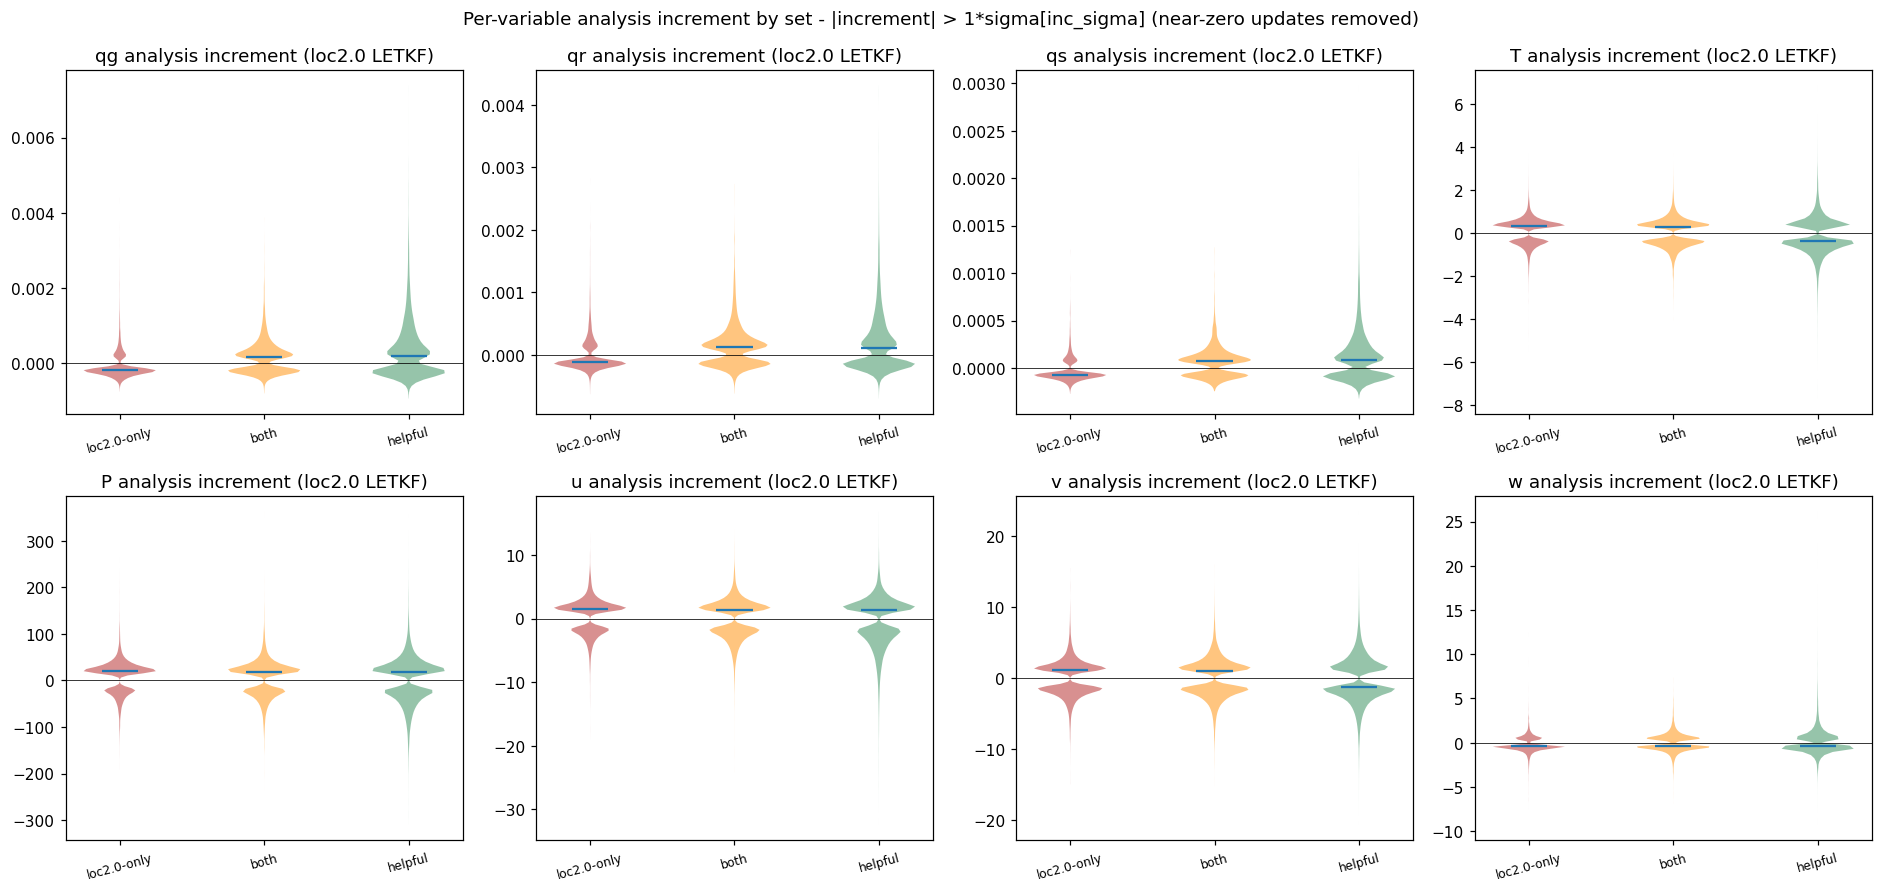

var           loc2.0-only                 both              helpful
qg           -0.0000   4%         +0.0000   4%         -0.0000  10%
qr           -0.0000   5%         -0.0000   4%         -0.0000  11%
qs           -0.0000   3%         +0.0000   4%         -0.0000  13%
T            +0.0231  15%         +0.0038  14%         +0.0036  25%
P            +1.4883  15%         +0.6758  14%         +1.0430  23%
u            +0.0835  12%         +0.0232  13%         +0.1160  24%
v            +0.0290  14%         +0.0188  14%         -0.0005  23%
w            -0.0077   8%         +0.0007   8%         -0.0079  15%


In [6]:
# helpful set: loc2.0 LETKF clearly improves reflectivity vs prior
helpful = common & (Ea_mo['loc2.0']['Nt1'] < Ef_mo['loc0.1'] - 0.5)
print(f'sets on common: loc2.0-only-patho={int(L20_ONLY.sum()):,}  both={int(L_BOTH.sum()):,}  helpful={int(helpful.sum()):,}')

# per-variable increment + local prior spread at loc2.0 (LETKF), from stored fields
with np.load(mo_combo('loc2.0', 'Nt1')) as f:
    inc20 = (f['bias_a_field'] - f['bias_f_field'])[I, J, K].astype(np.float64)   # (npts, 8)
    skw_a = f['skew_a_field'][I, J, K].astype(np.float64)
    sprd_f20 = f['spread_f_field'][I, J, K].astype(np.float64)                    # local prior spread (per var)

SETS = {'loc2.0-only': L20_ONLY, 'both': L_BOTH, 'helpful': helpful}
COLS = {'loc2.0-only': 'firebrick', 'both': 'darkorange', 'helpful': 'seagreen'}

# Near-zero cut: drop points whose analysis increment sits within +-KSIG*sigma of zero. Those
# untouched / noise-level updates pile up at inc=0 and swamp the pathological tails.
#   THRESH='inc_sigma'    -> sigma = std of that variable's increment over the common set (matches "increment +- sigma")
#   THRESH='prior_spread' -> sigma = local prior ensemble spread at each point (stricter, per-point)
KSIG   = 1.0
THRESH = 'inc_sigma'
sig_inc = np.array([np.nanstd(inc20[common, vi]) for vi in range(len(VARS))])     # per-variable increment sigma
def finite_col(msk, vi):
    v = inc20[msk, vi]
    if THRESH == 'prior_spread':
        sp = sprd_f20[msk, vi]
        keep = np.isfinite(v) & np.isfinite(sp) & (sp > 0) & (np.abs(v) > KSIG * sp)
    else:
        keep = np.isfinite(v) & (np.abs(v) > KSIG * sig_inc[vi])
    return v[keep]

fig, ax = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)
for vi, v in enumerate(VARS):
    a = ax.ravel()[vi]
    data = [finite_col(msk, vi) for msk in SETS.values()]
    parts = a.violinplot(data, showmedians=True, showextrema=False)
    for pc, c in zip(parts['bodies'], COLS.values()):
        pc.set_facecolor(c); pc.set_alpha(.5)
    a.set_xticks(range(1, len(SETS)+1)); a.set_xticklabels(list(SETS.keys()), rotation=15, fontsize=8)
    a.axhline(0, c='k', lw=.5); a.set_title(f'{v} analysis increment (loc2.0 LETKF)')
fig.suptitle(f'Per-variable analysis increment by set - |increment| > {KSIG:g}*sigma[{THRESH}] (near-zero updates removed)')
plt.show()

# median increment (all points) and the fraction of each set surviving the near-zero cut, per variable
print(f'{"var":4s} ' + ' '.join(f'{s:>20s}' for s in SETS))
for vi, v in enumerate(VARS):
    row = []
    for msk in SETS.values():
        tot = int(np.isfinite(inc20[msk, vi]).sum()); kept = finite_col(msk, vi).size
        row.append(f'{np.nanmedian(inc20[msk,vi]):+.4f} {100*kept/max(tot,1):3.0f}%')
    print(f'{v:4s} ' + ' '.join(f'{c:>20s}' for c in row))

## 4. Local reproduction of the multi-obs solve at representative points

Reproduce loc0.1 and loc2.0 LETKF on a subdomain around each representative, using that point's real
observation footprint. This yields the full posterior ensemble for every variable and is validated
against the stored fields.

In [7]:
def pick_rep(mask, score):
    idx = np.flatnonzero(mask)
    if idx.size == 0: return None
    p = idx[np.argmax(score[idx])]
    return (int(I[p]), int(J[p]), int(K[p]))
degrade = Ea_mo['loc2.0']['Nt1'] - Ef_mo['loc0.1']     # how much loc2.0 worsens reflectivity vs prior
REP = {}
for lbl, mk, sc in (('loc2.0-only', L20_ONLY, degrade),
                    ('both',        L_BOTH,   degrade),
                    ('helpful',     helpful,  -degrade)):
    c = pick_rep(mk, np.where(np.isfinite(sc), sc, -np.inf))
    if c: REP[lbl] = c
print('representatives:', REP)

LOC2 = 2.0; CUTOFF = 4.0
t0 = time.time()
BOX = {}
with np.load(SUBSET) as z:
    se = z['state_ensemble']; POS = z['pos_km'].astype(np.float32)
    for lbl, (i0, j0, k0) in REP.items():
        si, sj, sk = R._subdomain_slices(i0, j0, k0, LOC2, LOC2, LOC2, POS, NX, NY, NZ, CUTOFF)
        BOX[lbl] = dict(i0=i0, j0=j0, k0=k0, si=si, sj=sj, sk=sk,
                        xf=np.asfortranarray(se[si, sj, sk, 1:60, :].astype(np.float32)),
                        pos=np.asfortranarray(POS[si, sj, sk, :].astype(np.float32)),
                        truth=se[i0, j0, k0, TM, :].astype(np.float64).copy())
    del se
print(f'subset read + {len(BOX)} subdomains in {time.time()-t0:.0f}s')

def footprint(b, rmax=None):
    si, sj, sk = b['si'], b['sj'], b['sk']
    m = (IXO>=si.start)&(IXO<si.stop)&(IYO>=sj.start)&(IYO<sj.stop)&(IZO>=sk.start)&(IZO<sk.stop)
    ox=(IXO[m]-si.start).astype(np.int32); oy=(IYO[m]-sj.start).astype(np.int32); oz=(IZO[m]-sk.start).astype(np.int32)
    yb=YOO[m].astype(np.float32)
    if rmax is not None:
        ti,tj,tk = b['i0']-si.start, b['j0']-sj.start, b['k0']-sk.start
        dx=b['pos'][ox,oy,oz,0]-b['pos'][ti,tj,tk,0]; dy=b['pos'][ox,oy,oz,1]-b['pos'][ti,tj,tk,1]; dz=b['pos'][ox,oy,oz,2]-b['pos'][ti,tj,tk,2]
        keep=np.sqrt(dx**2+dy**2+dz**2)<=rmax
        ox,oy,oz,yb = ox[keep],oy[keep],oz[keep],yb[keep]
    return ox,oy,oz,yb

def solve(b, locval, step='Nt1', rmax=None):
    ox,oy,oz,yb = footprint(b, rmax)
    R0b = np.full(yb.size, R0, np.float32); loc = np.array([locval]*3, np.float32)
    if step == 'Nt1':
        xa = letkf_update(b['xf'], yb, R0b, ox, oy, oz, loc, VI, b['pos'], dbz_min=DBZ_MIN)['xa']
    else:
        xa = tenkf_update(b['xf'], yb, R0b, ox, oy, oz, loc, VI, int(step[2:]), 1.0, b['pos'], dbz_min=DBZ_MIN)['xa']
    ti,tj,tk = b['i0']-b['si'].start, b['j0']-b['sj'].start, b['k0']-b['sk'].start
    return xa[ti,tj,tk,:,:].astype(np.float64), yb.size    # posterior ensemble (Ne,8) at target

# validate reproduction vs stored fields at each representative
for lbl, b in BOX.items():
    ti,tj,tk = b['i0']-b['si'].start, b['j0']-b['sj'].start, b['k0']-b['sk'].start
    xf_t = b['xf'][ti,tj,tk,:,:].astype(np.float64); pri = xf_t.mean(0)
    for lk in ('loc0.1', 'loc2.0'):
        post, nob = solve(b, LOCVAL[lk], 'Nt1')
        repro_inc = post.mean(0) - pri
        with np.load(mo_combo(lk, 'Nt1')) as f:
            stored_inc = (f['bias_a_field'] - f['bias_f_field'])[b['i0'], b['j0'], b['k0']].astype(np.float64)
        worst = max(abs(repro_inc[VI[v]] - stored_inc[VI[v]]) / TOL[v] for v in VARS)
        print(f'{lbl:12s} {lk}: nobs={nob:4d}  reproduction vs stored (max ratio to tol) = {worst:.2f} '
              f'{"OK" if worst <= 1.5 else "FAIL"}')

representatives: {'loc2.0-only': (228, 370, 8), 'both': (196, 178, 5), 'helpful': (540, 368, 6)}
subset read + 3 subdomains in 50s
loc2.0-only  loc0.1: nobs= 275  reproduction vs stored (max ratio to tol) = 0.01 OK
loc2.0-only  loc2.0: nobs= 275  reproduction vs stored (max ratio to tol) = 0.01 OK
both         loc0.1: nobs= 275  reproduction vs stored (max ratio to tol) = 0.02 OK
both         loc2.0: nobs= 275  reproduction vs stored (max ratio to tol) = 0.02 OK
helpful      loc0.1: nobs= 272  reproduction vs stored (max ratio to tol) = 0.01 OK
helpful      loc2.0: nobs= 272  reproduction vs stored (max ratio to tol) = 0.01 OK


## 5. All-variable prior vs posterior ensembles at a representative point

For a localization-induced pathological point: the prior ensemble, and the posterior ensembles at
loc=0.1 (few obs, ~self column) and loc=2.0 (hundreds of obs). Reflectivity fits both ways, but the
unobserved variables are pushed much harder — and often outside the prior spread — at loc=2.0.

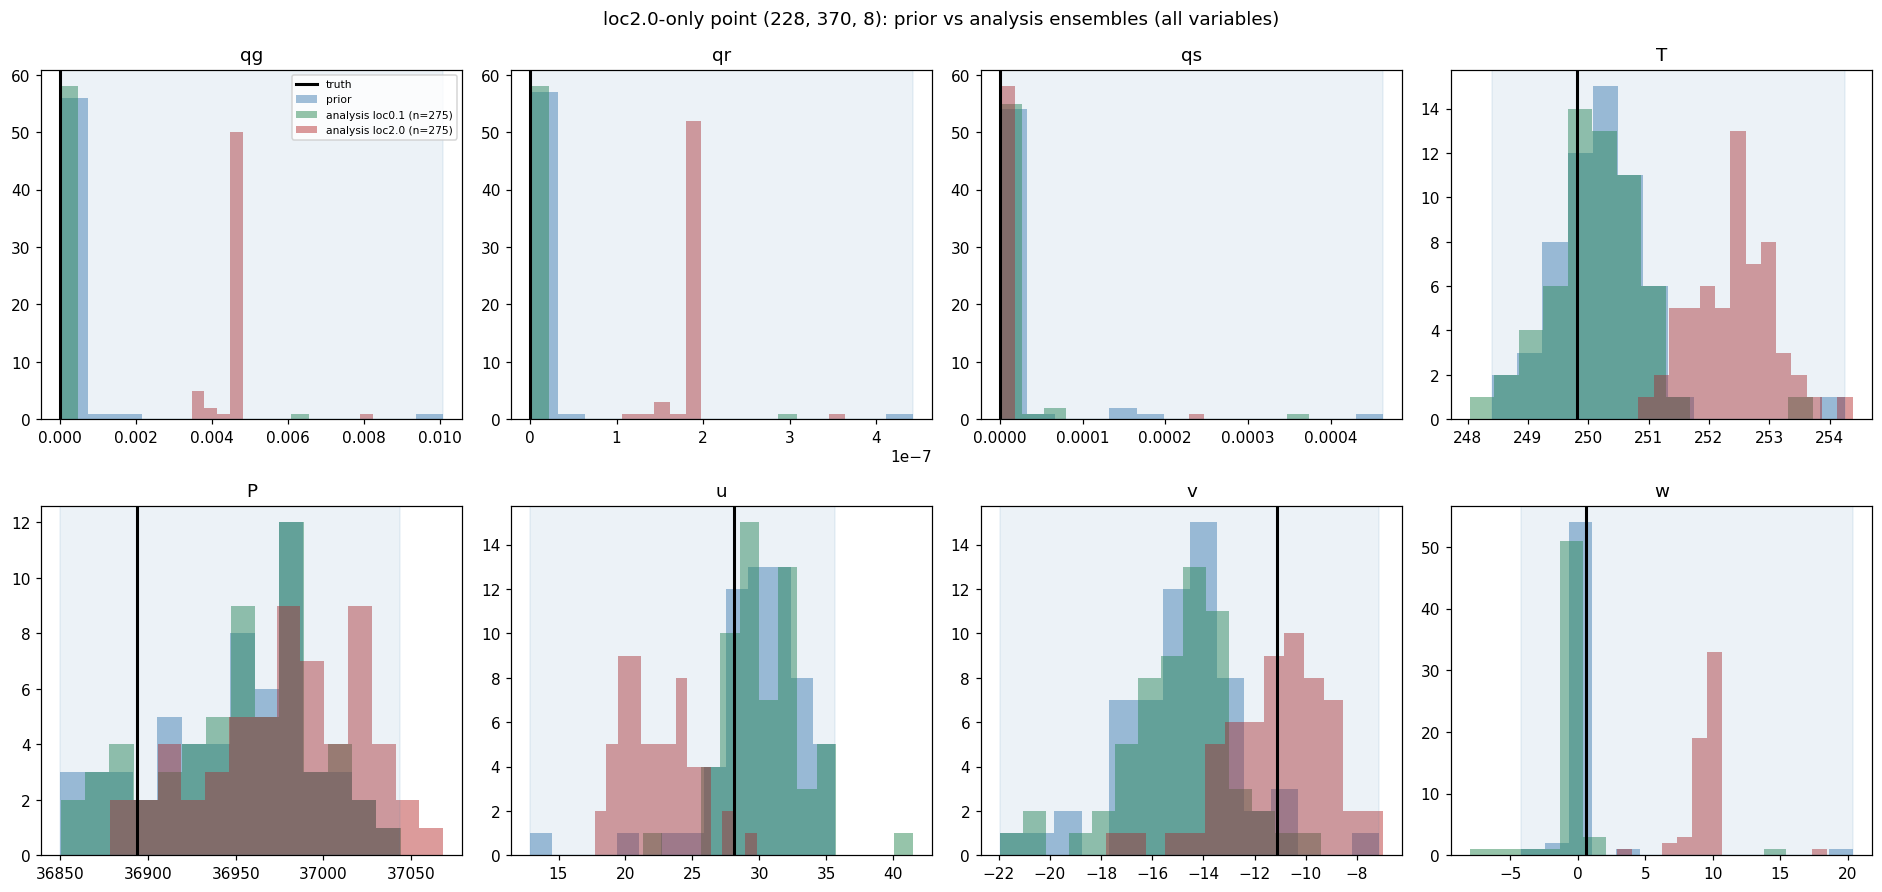

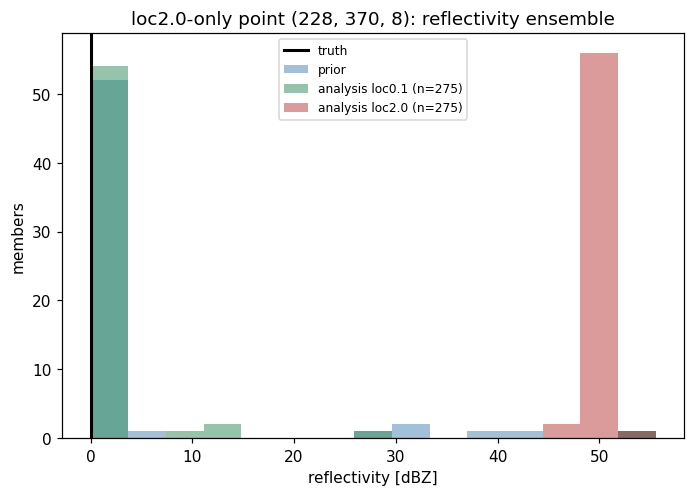

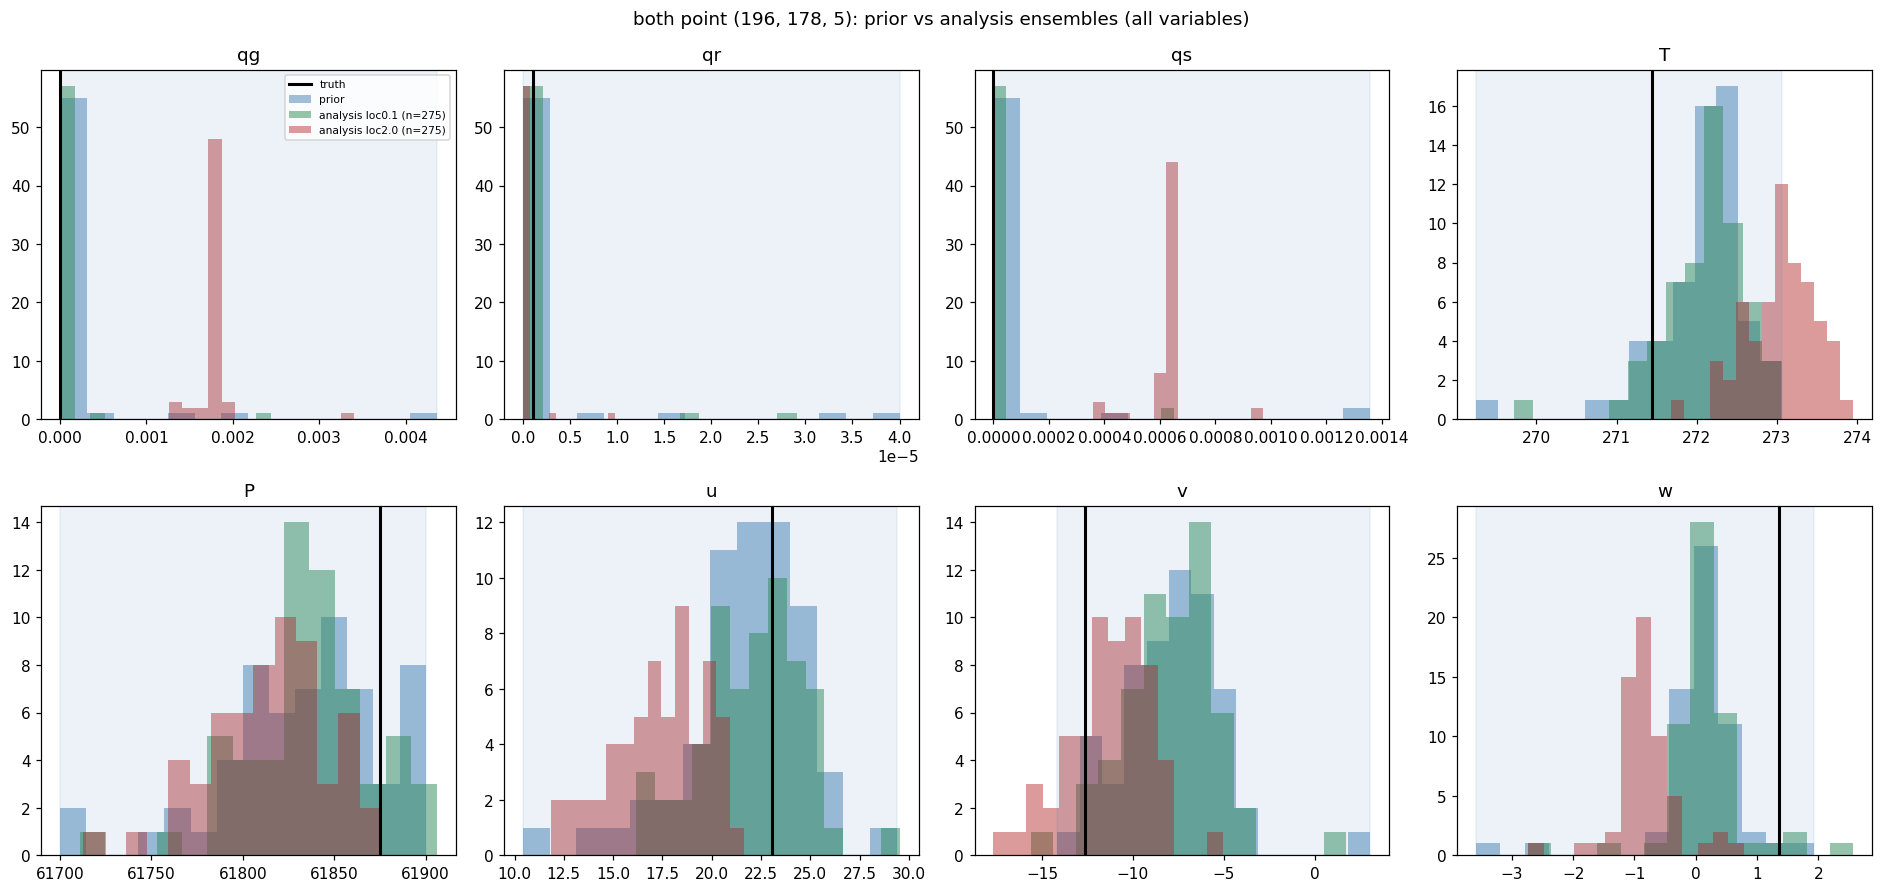

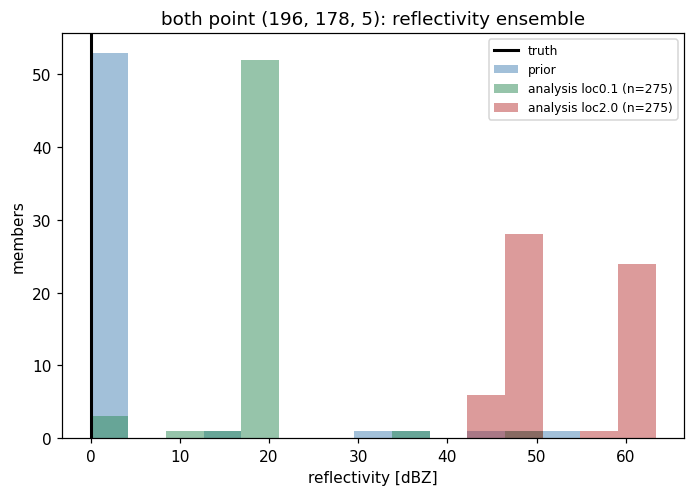

In [8]:
def ensemble_panel(lbl):
    b = BOX[lbl]
    ti,tj,tk = b['i0']-b['si'].start, b['j0']-b['sj'].start, b['k0']-b['sk'].start
    xf_t = b['xf'][ti,tj,tk,:,:].astype(np.float64)
    post01, n01 = solve(b, 0.1, 'Nt1'); post20, n20 = solve(b, 2.0, 'Nt1')
    truth = b['truth']
    # (a) all 8 state variables (each histogram = Ne ensemble members)
    fig, ax = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)
    for vi, v in enumerate(VARS):
        a = ax.ravel()[vi]
        a.hist(xf_t[:, vi], bins=14, color='steelblue', alpha=.5, label='prior')
        a.hist(post01[:, vi], bins=14, color='seagreen', alpha=.5, label=f'analysis loc0.1 (n={n01})')
        a.hist(post20[:, vi], bins=14, color='firebrick', alpha=.45, label=f'analysis loc2.0 (n={n20})')
        a.axvline(truth[vi], c='k', lw=2, label='truth')
        a.axvspan(xf_t[:, vi].min(), xf_t[:, vi].max(), color='steelblue', alpha=.10)
        a.set_title(v)
        if vi == 0: a.legend(fontsize=7)
    fig.suptitle(f'{lbl} point {(b["i0"],b["j0"],b["k0"])}: prior vs analysis ensembles (all variables)')
    plt.show()
    # (b) reflectivity ensemble: apply H per member -> Ne dBZ values. Separate figure to keep the 2x4 symmetry.
    hf, h01, h20 = Hmembers(xf_t), Hmembers(post01), Hmembers(post20)
    htr = float(Hmembers(truth))
    lo = min(hf.min(), h01.min(), h20.min()); hi = max(hf.max(), h01.max(), h20.max())
    bins = np.linspace(lo, hi, 16) if hi > lo else 14
    fig2, a2 = plt.subplots(figsize=(6.2, 4.4), constrained_layout=True)
    a2.hist(hf,  bins=bins, color='steelblue', alpha=.5, label='prior')
    a2.hist(h01, bins=bins, color='seagreen',  alpha=.5, label=f'analysis loc0.1 (n={n01})')
    a2.hist(h20, bins=bins, color='firebrick', alpha=.45, label=f'analysis loc2.0 (n={n20})')
    a2.axvline(htr, c='k', lw=2, label='truth')
    a2.set_xlabel('reflectivity [dBZ]'); a2.set_ylabel('members')
    a2.set_title(f'{lbl} point {(b["i0"],b["j0"],b["k0"])}: reflectivity ensemble'); a2.legend(fontsize=8)
    plt.show()

for lbl in ('loc2.0-only', 'both'):
    if lbl in BOX: ensemble_panel(lbl)

## 5b. Pooled ensembles over ALL tempering-degrades points (loc2.0)

Instead of one representative, pool the full posterior ensemble (Ne members) over a random subsample
of **every** tempering-degrades point (the ~51k points where the tempered Nt2 analysis reflectivity is
worse than *both* the prior and plain LETKF). With thousands of points × Ne members the histograms
become smooth, so any systematic distributional signature — members piling up at a value, or the
hydrometeor zero-floor being depleted — becomes visible.

- **prior**, **loc0.1** (LETKF), **loc2.0** (LETKF) and **loc2.0 Nt2** (the tempered analysis that
  *defines* the set) are compared; **reflectivity is a separate figure** (H applied per member).
- Analysis ensembles are **reconstructed** with the validated per-point `solve()` (they are not stored).
- `LOGY=True` keeps the zero / near-zero pile from hiding the tails. Set `CENTER=True` to plot the
  anomaly vs each point's prior mean — this removes the height dependence so **P** and **T** become
  comparable across the heterogeneous pooled points (raw P mixes vertical levels). Raise `NSAMP` for
  smoother tails (`~8 min` per 2000 points); the alternative 54,518-point set is one commented line above.

tempering-degrades loc2.0 pathological points: 51,045
state_ensemble (558, 898, 11, 60, 8) resident in 50s
  500/2000  (258 ms/pt)
  1000/2000  (261 ms/pt)
  1500/2000  (262 ms/pt)
  2000/2000  (262 ms/pt)
pooled 118,000 member-values/series in 523s (Ne=59)


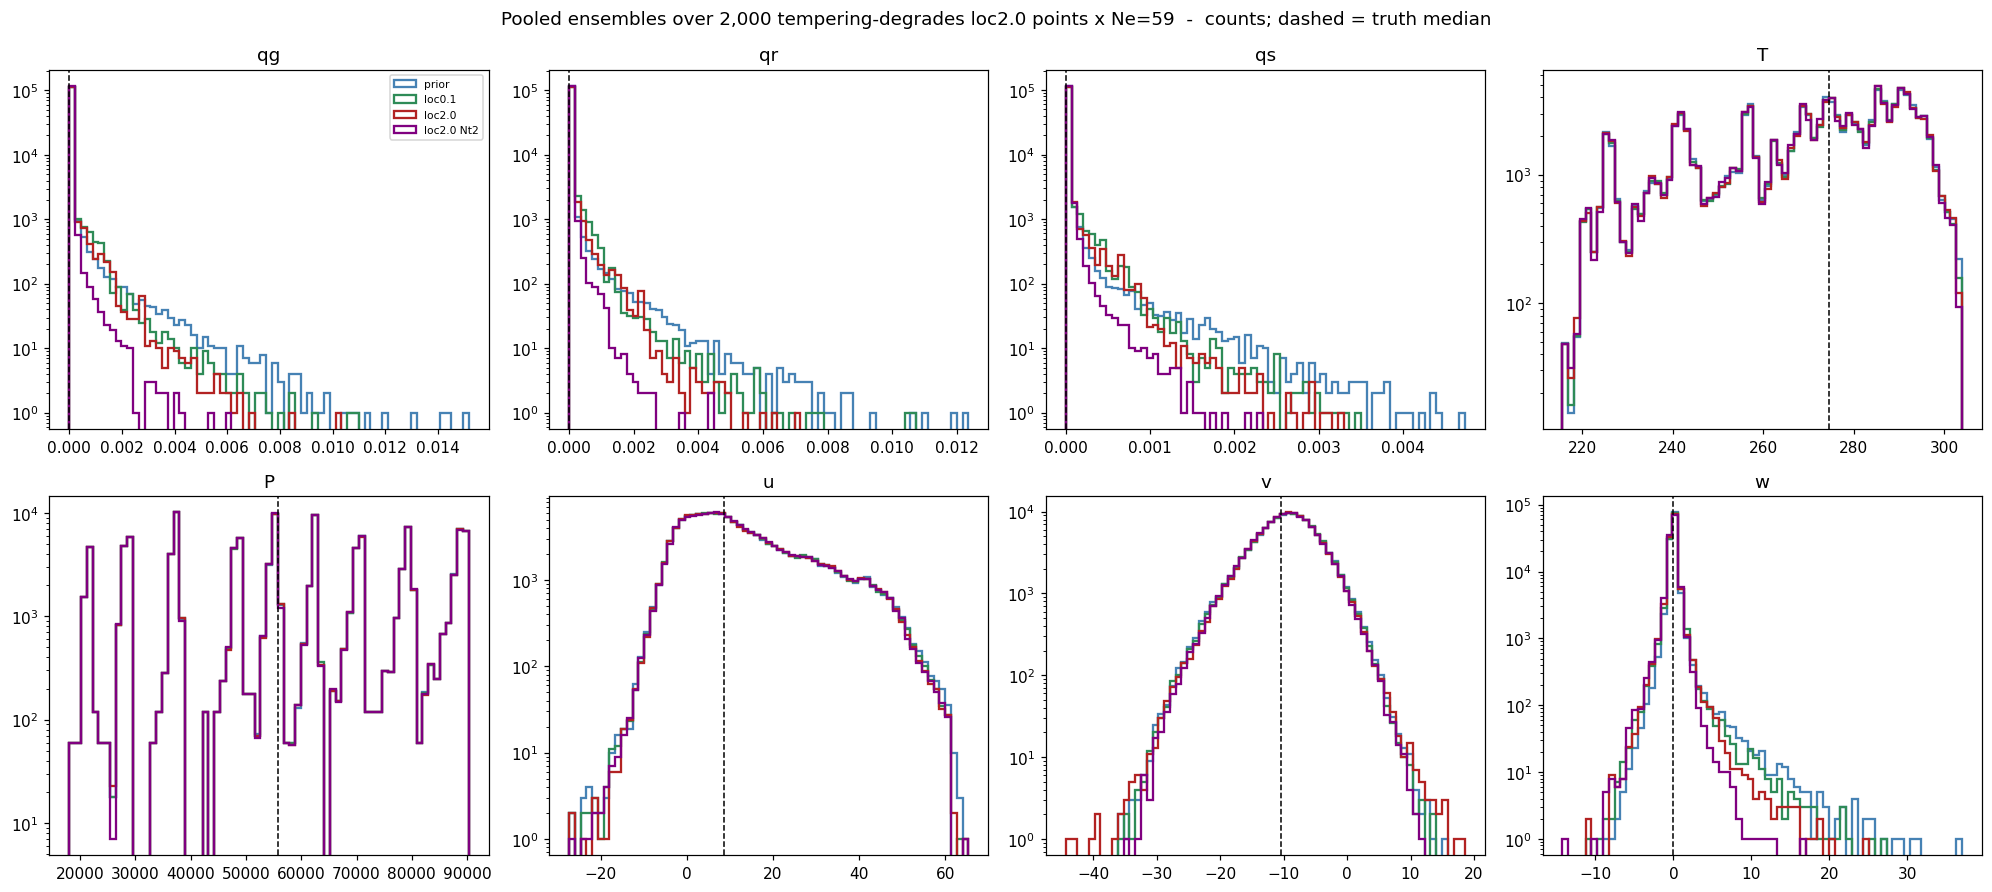

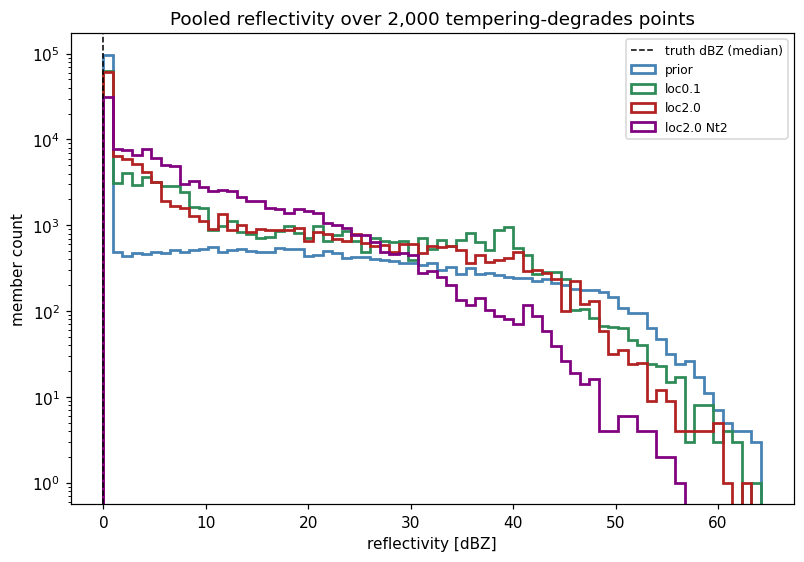

fraction of pooled members at/below 0 (clear air / no hydrometeor):
  prior        qg=79.42%  qr=78.52%  qs=79.36%
  loc0.1       qg=63.04%  qr=60.13%  qs=64.11%
  loc2.0       qg=57.00%  qr=51.82%  qs=59.17%
  loc2.0 Nt2   qg=55.27%  qr=47.57%  qs=58.54%


In [9]:
# ----- pathological set: tempering (Nt2) reflectivity worse than BOTH prior and plain LETKF (Nt1) -----
patho = (common
         & (Ea_mo['loc2.0']['Nt2'] > Ef_mo['loc2.0'] + 1e-4)
         & (Ea_mo['loc2.0']['Nt2'] > Ea_mo['loc2.0']['Nt1'] + 1e-4))
# alt (the 54,518 localization-induced Nt2 set printed in section 2):
#   patho = common & (Ea_mo['loc2.0']['Nt2'] > Ef_mo['loc0.1']+1e-4) & ~(Ea_mo['loc0.1']['Nt2'] > Ef_mo['loc0.1']+1e-4)
print(f'tempering-degrades loc2.0 pathological points: {int(patho.sum()):,}')

NSAMP  = 2000     # random subsample; each point contributes Ne(=59) real members  (~8 min for x3 solves/pt)
CENTER = False    # False: raw ensemble values (as requested). True: anomaly vs per-point prior mean
                  #        (removes the height dependence, so P/T become comparable across pooled points).
LOGY   = True     # log count axis so the zero / near-zero pile does not hide the tails
SERIES = ['prior', 'loc0.1', 'loc2.0', 'loc2.0 Nt2']   # loc2.0 Nt2 = the tempered analysis that defines the set
COL    = {'prior':'steelblue', 'loc0.1':'seagreen', 'loc2.0':'firebrick', 'loc2.0 Nt2':'purple'}

# prior ensemble field resident (needed to build a subdomain per sampled point); reuse if already loaded
if 'SE' not in globals():
    t0 = time.time()
    with np.load(SUBSET) as z:
        SE = z['state_ensemble']                        # (NX,NY,NZ,60,8), ~10 GB
        POS_full = np.asfortranarray(z['pos_km'].astype(np.float32))
    print(f'state_ensemble {SE.shape} resident in {time.time()-t0:.0f}s')

def make_box(i0, j0, k0):
    si, sj, sk = R._subdomain_slices(i0, j0, k0, LOC2, LOC2, LOC2, POS_full, NX, NY, NZ, CUTOFF)
    return dict(i0=i0, j0=j0, k0=k0, si=si, sj=sj, sk=sk,
                xf=np.asfortranarray(SE[si, sj, sk, 1:60, :].astype(np.float32)),
                pos=np.asfortranarray(POS_full[si, sj, sk, :].astype(np.float32)),
                truth=SE[i0, j0, k0, TM, :].astype(np.float64).copy())

rng = np.random.default_rng(0)
sel = rng.choice(np.flatnonzero(patho), size=min(NSAMP, int(patho.sum())), replace=False)
stack = {s: [] for s in SERIES}; pri_mean = []; tru = []
t0 = time.time()
for n, c in enumerate(sel, 1):
    i0, j0, k0 = int(I[c]), int(J[c]), int(K[c])
    b = make_box(i0, j0, k0)
    ti, tj, tk = i0-b['si'].start, j0-b['sj'].start, k0-b['sk'].start
    prior = b['xf'][ti, tj, tk, :, :].astype(np.float64)          # (Ne,8)
    stack['prior'].append(prior)
    stack['loc0.1'].append(solve(b, 0.1, 'Nt1')[0])
    stack['loc2.0'].append(solve(b, 2.0, 'Nt1')[0])
    stack['loc2.0 Nt2'].append(solve(b, 2.0, 'Nt2')[0])
    pri_mean.append(prior.mean(0)); tru.append(b['truth'])
    if n % 500 == 0: print(f'  {n}/{sel.size}  ({(time.time()-t0)/n*1000:.0f} ms/pt)')
Ne = stack['prior'][0].shape[0]; pri_mean = np.array(pri_mean); tru = np.array(tru)
print(f'pooled {len(sel)*Ne:,} member-values/series in {time.time()-t0:.0f}s (Ne={Ne})')

raw  = {s: np.stack(stack[s], 0).reshape(-1, 8) for s in SERIES}   # raw pooled values (npt*Ne, 8)
prim = np.repeat(pri_mean, Ne, axis=0)                            # per-member prior mean
pool = {s: (raw[s] - prim if CENTER else raw[s]) for s in SERIES}
truth_v = (tru - pri_mean) if CENTER else tru

# ----- figure 1: pooled state-variable distributions -----
fig, ax = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
for vi, v in enumerate(VARS):
    a = ax.ravel()[vi]
    lo = min(pool[s][:, vi].min() for s in SERIES); hi = max(pool[s][:, vi].max() for s in SERIES)
    bins = np.linspace(lo, hi, 70)
    for s in SERIES:
        a.hist(pool[s][:, vi], bins=bins, histtype='step', lw=1.5, color=COL[s], label=s)
    a.axvline(np.median(truth_v[:, vi]), c='k', lw=1, ls='--')
    if LOGY: a.set_yscale('log')
    a.set_title(v + (' (anomaly)' if CENTER else ''))
    if vi == 0: a.legend(fontsize=7)
fig.suptitle(f'Pooled ensembles over {len(sel):,} tempering-degrades loc2.0 points x Ne={Ne}'
             f'{" (centered on prior mean)" if CENTER else ""}  -  counts; dashed = truth median')
plt.show()

# ----- figure 2: pooled reflectivity (separate; H is on absolute state, so always from raw values) -----
refs = {s: Hmembers(raw[s]) for s in SERIES}; tref = Hmembers(tru)
fig2, a2 = plt.subplots(figsize=(7.2, 5), constrained_layout=True)
lo = min(refs[s].min() for s in SERIES); hi = max(refs[s].max() for s in SERIES)
bins = np.linspace(lo, hi, 70)
for s in SERIES:
    a2.hist(refs[s], bins=bins, histtype='step', lw=1.8, color=COL[s], label=s)
a2.axvline(np.median(tref), c='k', lw=1, ls='--', label='truth dBZ (median)')
if LOGY: a2.set_yscale('log')
a2.set_xlabel('reflectivity [dBZ]'); a2.set_ylabel('member count')
a2.set_title(f'Pooled reflectivity over {len(sel):,} tempering-degrades points'); a2.legend(fontsize=8)
plt.show()

# ----- hydrometeor zero-floor occupancy (the 'piling at a value' diagnostic) -----
print('fraction of pooled members at/below 0 (clear air / no hydrometeor):')
for s in SERIES:
    fr = {vv: float(np.mean(raw[s][:, VI[vv]] <= 1e-9)) for vv in ('qg','qr','qs')}
    print(f'  {s:11s}  qg={fr["qg"]:6.2%}  qr={fr["qr"]:6.2%}  qs={fr["qs"]:6.2%}')

## 6. The localization mechanism: near vs far obs, and spurious correlations

Grow the observation radius at loc=2.0 and watch the increment converge. Then compare each footprint
observation's `cov(var, dBZ_obs)` against the sampling-noise floor `sigma_var*sigma_h/sqrt(Ne-1)`:
far obs carry near-noise-floor (spurious) covariance yet still contribute through the localization
weight, and their accumulated effect is the localization damage.

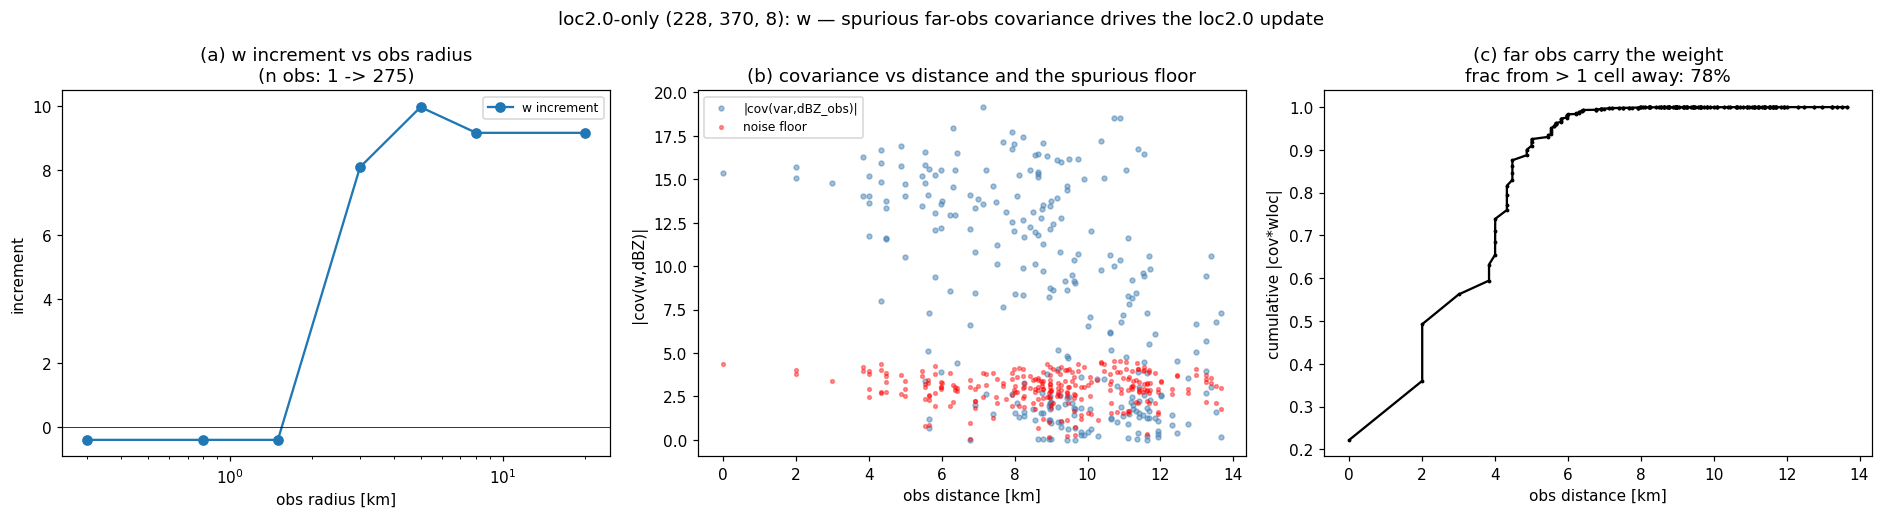

loc2.0-only w: increment self-only=-0.390 -> full=+9.172 m/s ; far-obs (>1 cell) carry 78% of the weighted covariance; median |cov|/floor far = 2.41


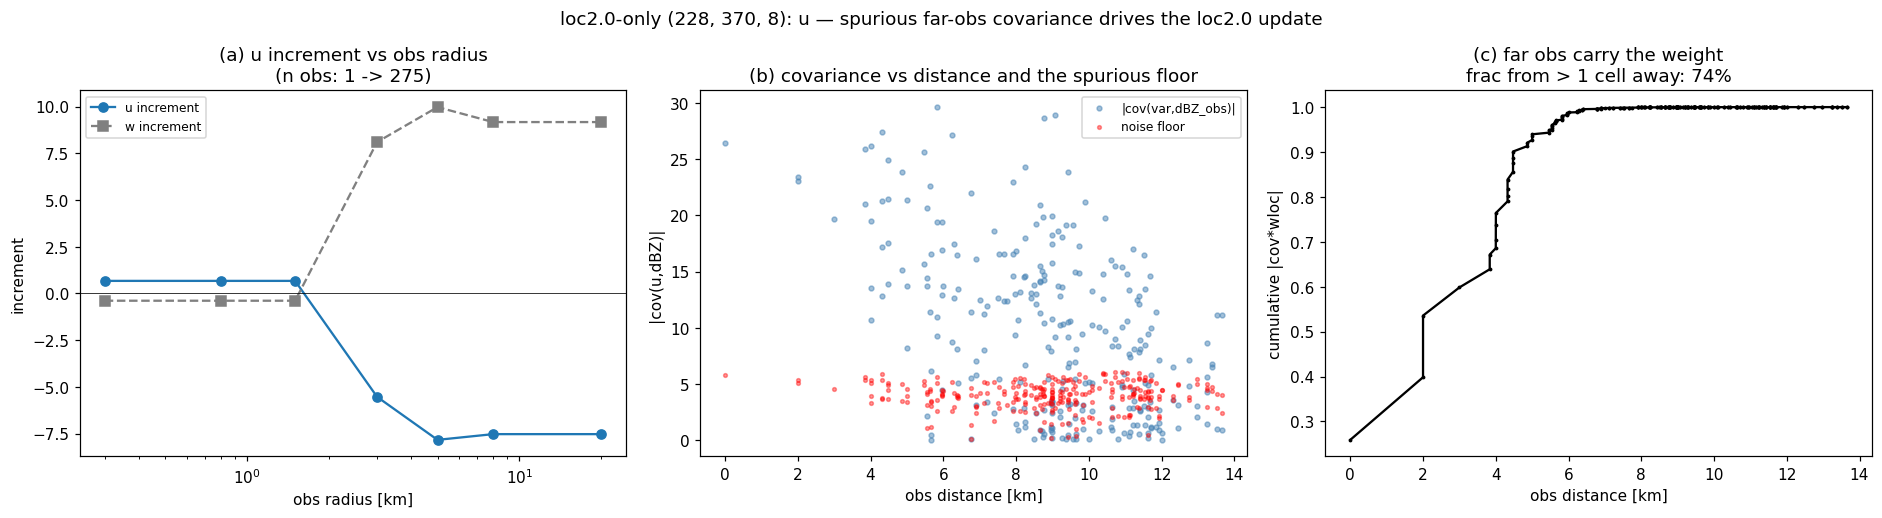

loc2.0-only u: increment self-only=+0.672 -> full=-7.531 m/s ; far-obs (>1 cell) carry 74% of the weighted covariance; median |cov|/floor far = 2.03


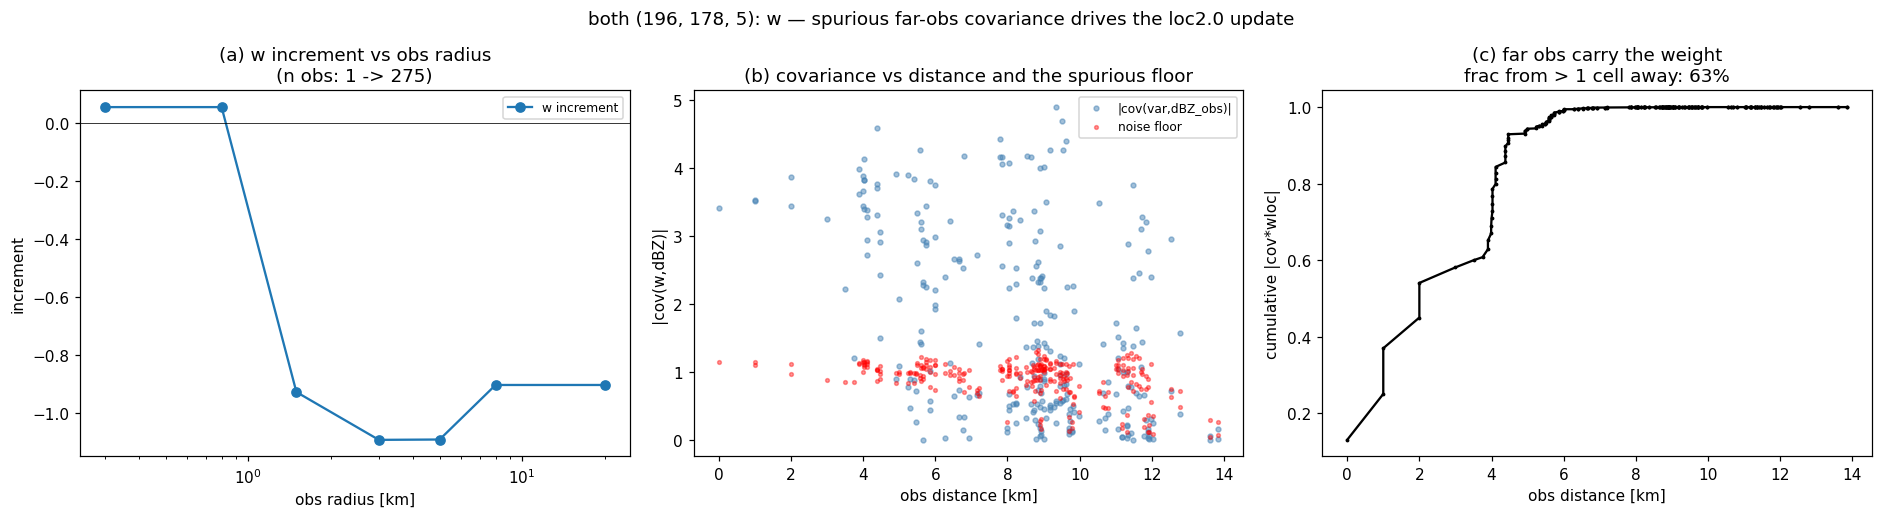

both w: increment self-only=+0.054 -> full=-0.904 m/s ; far-obs (>1 cell) carry 63% of the weighted covariance; median |cov|/floor far = 1.28


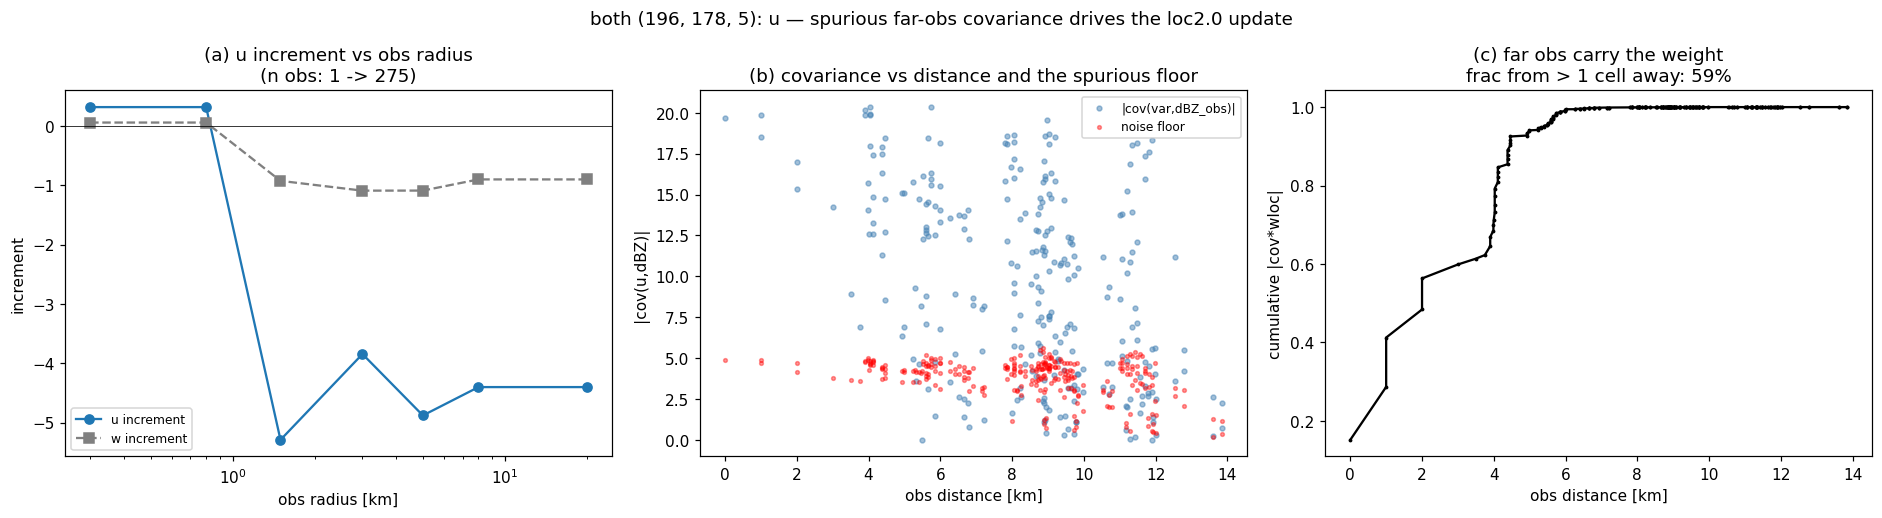

both u: increment self-only=+0.314 -> full=-4.402 m/s ; far-obs (>1 cell) carry 59% of the weighted covariance; median |cov|/floor far = 2.24


In [10]:
def mechanism(lbl, var='w'):
    b = BOX[lbl]; vi = VI[var]
    ti,tj,tk = b['i0']-b['si'].start, b['j0']-b['sj'].start, b['k0']-b['sk'].start
    pri = b['xf'][ti,tj,tk,:,:].astype(np.float64).mean(0)

    # (a) increment vs observation radius
    radii = [0.3, 0.8, 1.5, 3.0, 5.0, 8.0, 20.0]
    inc_v, inc_w, nobs = [], [], []
    for rmax in radii:
        post, nob = solve(b, 2.0, 'Nt1', rmax=rmax)
        inc_v.append(post.mean(0)[vi] - pri[vi]); inc_w.append(post.mean(0)[IW] - pri[IW]); nobs.append(nob)

    # (b) cov(var, dBZ_obs) of every footprint obs vs distance, with the sampling-noise floor
    ox,oy,oz,yb = footprint(b)
    xf_box = b['xf']                                  # (ni,nj,nk,Ne,8)
    NE = xf_box.shape[3]
    h_obs = Hmembers(np.moveaxis(xf_box[ox,oy,oz,:,:], 0, 0))   # (nobs, Ne)
    var_t = b['xf'][ti,tj,tk,:,vi].astype(np.float64)          # target var ensemble (Ne,)
    vt = var_t - var_t.mean()
    ho = h_obs.astype(np.float64) - h_obs.astype(np.float64).mean(1, keepdims=True)
    cov = (vt[None, :] * ho).sum(1) / (NE - 1)                 # cov(var_target, dBZ_obs) per obs
    dx=b['pos'][ox,oy,oz,0]-b['pos'][ti,tj,tk,0]; dy=b['pos'][ox,oy,oz,1]-b['pos'][ti,tj,tk,1]; dz=b['pos'][ox,oy,oz,2]-b['pos'][ti,tj,tk,2]
    dist = np.sqrt(dx**2 + dy**2 + dz**2)
    sig_v = var_t.std(ddof=1); sig_h = h_obs.astype(np.float64).std(1, ddof=1)
    floor = sig_v * sig_h / np.sqrt(NE - 1)                    # spurious-correlation noise floor
    wloc = np.exp(-0.5 * (dist / 2.0) ** 2)                    # loc=2.0 Gaussian weight (approx)

    fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    ax[0].plot(radii, inc_v, 'o-', label=f'{var} increment')
    if var != 'w': ax[0].plot(radii, inc_w, 's--', color='gray', label='w increment')
    ax[0].set_xscale('log'); ax[0].axhline(0, c='k', lw=.5)
    ax[0].set_xlabel('obs radius [km]'); ax[0].set_ylabel('increment')
    ax[0].set_title(f'(a) {var} increment vs obs radius\n(n obs: {nobs[0]} -> {nobs[-1]})'); ax[0].legend(fontsize=8)
    ax[1].scatter(dist, np.abs(cov), s=10, c='steelblue', alpha=.5, label='|cov(var,dBZ_obs)|')
    ax[1].scatter(dist, floor, s=6, c='red', alpha=.4, label='noise floor')
    ax[1].set_xlabel('obs distance [km]'); ax[1].set_ylabel(f'|cov({var},dBZ)|')
    ax[1].set_title('(b) covariance vs distance and the spurious floor'); ax[1].legend(fontsize=8)
    order = np.argsort(dist)
    contrib = np.abs(cov * wloc)
    ax[2].plot(dist[order], np.cumsum(contrib[order]) / contrib.sum(), 'k.-', ms=3)
    frac_far = contrib[dist >= 1.6].sum() / contrib.sum()
    ax[2].set_xlabel('obs distance [km]'); ax[2].set_ylabel('cumulative |cov*wloc|')
    ax[2].set_title(f'(c) far obs carry the weight\nfrac from > 1 cell away: {frac_far:.0%}')
    fig.suptitle(f'{lbl} {(b["i0"],b["j0"],b["k0"])}: {var} — spurious far-obs covariance drives the loc2.0 update')
    plt.show()
    print(f'{lbl} {var}: increment self-only={inc_v[0]:+.3f} -> full={inc_v[-1]:+.3f} m/s ; '
          f'far-obs (>1 cell) carry {frac_far:.0%} of the weighted covariance; '
          f'median |cov|/floor far = {np.nanmedian((np.abs(cov)/floor)[dist>=1.6]):.2f}')

for lbl in ('loc2.0-only', 'both'):
    if lbl in BOX:
        mechanism(lbl, 'w')
        mechanism(lbl, 'u')

## 7. Summary and export

In [11]:
np.savez_compressed(
    f'{D}/derived_S11_sets.npz',
    i=I, j=J, k=K, common=common,
    Ef_prior=Ef_mo['loc0.1'],
    Ea_sweep_Nt1=Ea_sw['Nt1'], Ea_loc01_Nt1=Ea_mo['loc0.1']['Nt1'], Ea_loc20_Nt1=Ea_mo['loc2.0']['Nt1'],
    Ea_loc20_Nt2=Ea_mo['loc2.0']['Nt2'],
    patho_loc20_only=L20_ONLY, patho_both=L_BOTH, helpful=helpful,
    wf_loc20=wf_mo['loc2.0'], wa_loc20=wa_mo['loc2.0'], wt=wt,
)
print('saved', f'{D}/derived_S11_sets.npz')
print(f'\nSummary (Ne=59, 1800 UTC, common k>=2 = {int(common.sum()):,} points):')
print(f'  LETKF reflectivity worse than prior:  loc0.1={int(P_L01.sum()):,}  loc2.0={int(P_L20.sum()):,}')
print(f'  localization-induced (loc2.0 only) :  {int(L20_ONLY.sum()):,}')
print(f'  clean at loc2.0 but bad at loc0.1   :  {int((P_L01 & ~P_L20).sum()):,}  (one-way hypothesis)')
print(f'  w error worse at loc2.0 than loc0.1 :  {np.nanmean((np.abs(wa_mo["loc2.0"]-wt) > np.abs(wa_mo["loc0.1"]-wt))[common]):.1%}')
assert int(L20_ONLY.sum()) > 0 and int(helpful.sum()) > 0, 'empty target sets'
print('\nVERIFICATION OK')

saved /nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived_S11_sets.npz

Summary (Ne=59, 1800 UTC, common k>=2 = 554,921 points):
  LETKF reflectivity worse than prior:  loc0.1=144,746  loc2.0=242,651
  localization-induced (loc2.0 only) :  130,254
  clean at loc2.0 but bad at loc0.1   :  32,349  (one-way hypothesis)
  w error worse at loc2.0 than loc0.1 :  51.7%

VERIFICATION OK
